In [9]:
# Importations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Chargement du fichier CSV complet
df_full = pd.read_csv("donnees_finales.csv", low_memory=False)

# Échantillonnage pour réduire la taille si nécessaire
df = df_full.sample(n=700000, random_state=42)

# On garde uniquement les lignes avec une étiquette DPE connue
df = df[df['etiquette_dpe'].notna()]

print(df.shape)
df.head()


(700000, 25)


,conso_5_usages_ef,version_dpe,qualite_isolation_murs,type_batiment,classe_altitude,type_installation_ecs,type_energie_principale_chauffage,qualite_isolation_plancher_bas,adresse_ban,modele_dpe,...,_score,nombre_niveau_logement,isolation_toiture,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal,type_generateur_froid,_outlier,TX,TN,periode_construction
1105079,6602.8,1.0,insuffisante,appartement,inférieur à 400m,individuel,Électricité,insuffisante,1 Rue Voltaire 07400 Le Teil,DPE 3CL 2021 méthode logement,...,NaN,1.0,NaN,non spécifié,non spécifié,NaN,False,23.4,13.7,Avant 1960
279131,4289.5,2.2,insuffisante,appartement,inférieur à 400m,individuel,Électricité,NaN,136 Rue Antoine Charial 69003 Lyon,DPE 3CL 2021 méthode logement,...,NaN,1.0,1.0,Ballon électrique,radiateur électrique,NaN,False,8.7,2.0,Après 2010
896219,10395.1,2.2,insuffisante,appartement,inférieur à 400m,individuel,Gaz naturel,très bonne,3 Allée des Acacias 69310 Pierre-Bénite,DPE 3CL 2021 méthode logement,...,NaN,1.0,1.0,Ballon électrique,Chaudière gaz,NaN,False,19.5,8.2,NaN
1607041,13597.4,2.4,insuffisante,appartement,inférieur à 400m,collectif,Gaz naturel,très bonne,41 rue des Gravouses 63100 Clermont-Ferrand,DPE 3CL 2021 méthode logement,...,NaN,1.0,1.0,chaudière condensation,Chaudière gaz,NaN,False,8.3,0.4,1961 - 1970
1291866,48296.0,2.4,insuffisante,maison,inférieur à 400m,NaN,Gaz naturel,insuffisante,Grande Rue de Bulliez 01150 Lagnieu,DPE 3CL 2021 méthode logement,...,NaN,2.0,1.0,Chaudière gaz,Chaudière gaz,PAC air/air installée avant 2008,False,10.4,2.3,Avant 1960


In [10]:
# Variables explicatives choisies
ls_variables_explicatives = [
    'qualite_isolation_murs',
    'type_batiment',
    'type_installation_ecs',
    'type_energie_principale_chauffage',
    'qualite_isolation_plancher_bas',
    'type_installation_chauffage',
    'surface_habitable_logement',
    'hauteur_sous_plafond',
    'nombre_niveau_logement',
    'isolation_toiture',
    'type_generateur_n1_ecs_n1',
    'type_generateur_chauffage_principal',
    'periode_construction'
]

# Vérification existence
ls_variables_explicatives = [col for col in ls_variables_explicatives if col in df.columns]

# Nettoyage / imputation
for col in ls_variables_explicatives:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Variable cible
y = df['etiquette_dpe']

# Encodage des variables catégorielles
X = pd.get_dummies(df[ls_variables_explicatives], drop_first=True)

print("Données prêtes :", X.shape)
print(df['etiquette_dpe'].value_counts(normalize=True).round(3))


Données prêtes : (700000, 65)
etiquette_dpe
C    0.316
D    0.289
E    0.191
F    0.078
G    0.056
B    0.044
A    0.027
Name: proportion, dtype: float64


In [11]:
# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("X_train :", X_train.shape, "X_test :", X_test.shape)
print("Distribution des classes (train) :")
print(y_train.value_counts())


X_train : (490000, 65) X_test : (210000, 65)
Distribution des classes (train) :
etiquette_dpe
C    154921
D    141796
E     93402
F     38067
G     27267
B     21514
A     13033
Name: count, dtype: int64


In [12]:
# Application de SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAprès SMOTE :")
print(y_train_res.value_counts())
print("X_train_res :", X_train_res.shape)



Après SMOTE :
etiquette_dpe
D    154921
C    154921
E    154921
B    154921
G    154921
F    154921
A    154921
Name: count, dtype: int64
X_train_res : (1084447, 65)


In [13]:
# Encode target labels pour XGBoost
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_res)
y_test_enc = le.transform(y_test)

# Définition du modèle XGBoost multi-class (modèle optimisé)
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Entraînement
xgb_model.fit(X_train_res, y_train_enc)

print(" Modèle XGBoost entraîné avec succès.")


 Modèle XGBoost entraîné avec succès.



🎯 Rapport de classification :
              precision    recall  f1-score   support

           A       0.68      0.81      0.74      5585
           B       0.37      0.66      0.48      9221
           C       0.76      0.63      0.69     66395
           D       0.54      0.55      0.55     60770
           E       0.44      0.43      0.43     40029
           F       0.30      0.24      0.27     16314
           G       0.40      0.60      0.48     11686

    accuracy                           0.54    210000
   macro avg       0.50      0.56      0.52    210000
weighted avg       0.56      0.54      0.55    210000

Accuracy : 0.543


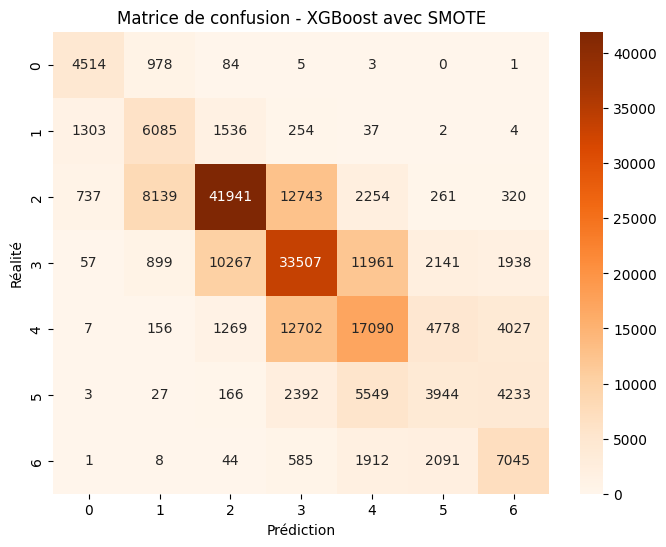

In [14]:
# Prédiction sur le test set
y_pred_enc = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("\n🎯 Rapport de classification :")
print(classification_report(y_test, y_pred))

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))

# Matrice de confusion
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Matrice de confusion - XGBoost avec SMOTE")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.show()


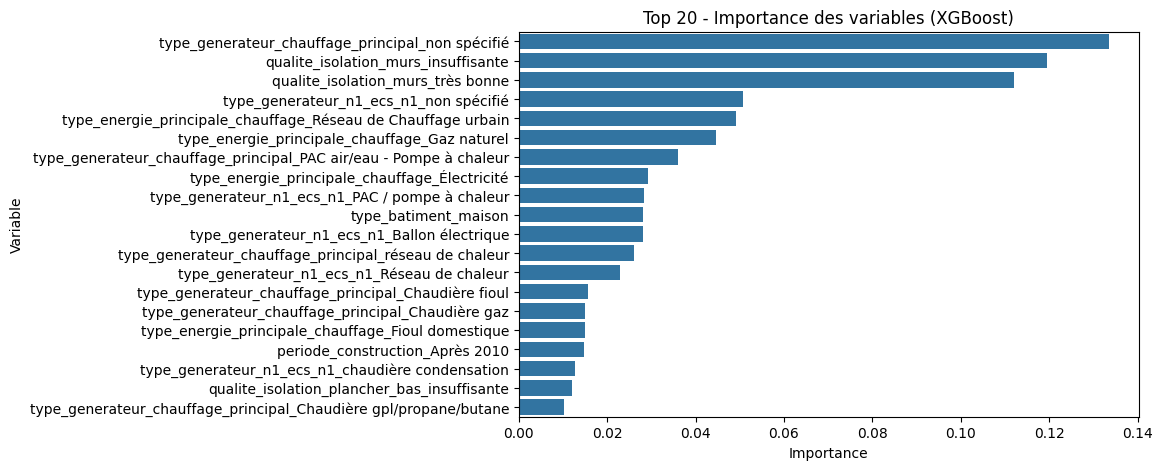

In [15]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 20 - Importance des variables (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()


In [16]:
import joblib

# Enregistrer le modèle XGBoost entraîné (avant optimisation)
joblib.dump(xgb_model, "modele_dpe_xgb2.pkl")

print("Modèle sauvegardé dans 'modele_dpe_xgb2.pkl'")


Modèle sauvegardé dans 'modele_dpe_xgb2.pkl'


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st

# Paramètres à tester
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Entraînement
random_search.fit(X_train_res, y_train_enc)

# Meilleurs paramètres
print("Meilleurs paramètres trouvés :")
print(random_search.best_params_)

# Remplacer le modèle par le meilleur
best_xgb_model = random_search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# Prédiction sur le test set avec le modèle optimisé
y_pred_enc_opt = best_xgb_model.predict(X_test)
y_pred_opt = le.inverse_transform(y_pred_enc_opt)

print("\n🎯 Rapport de classification - modèle optimisé :")
print(classification_report(y_test, y_pred_opt))

print("Accuracy :", round(accuracy_score(y_test, y_pred_opt), 3))
